Final training accuracy: 0.9268
Final test accuracy: 0.8550
Best test accuracy: 0.8580
Final training loss: 0.029049
Final test loss: 0.038043


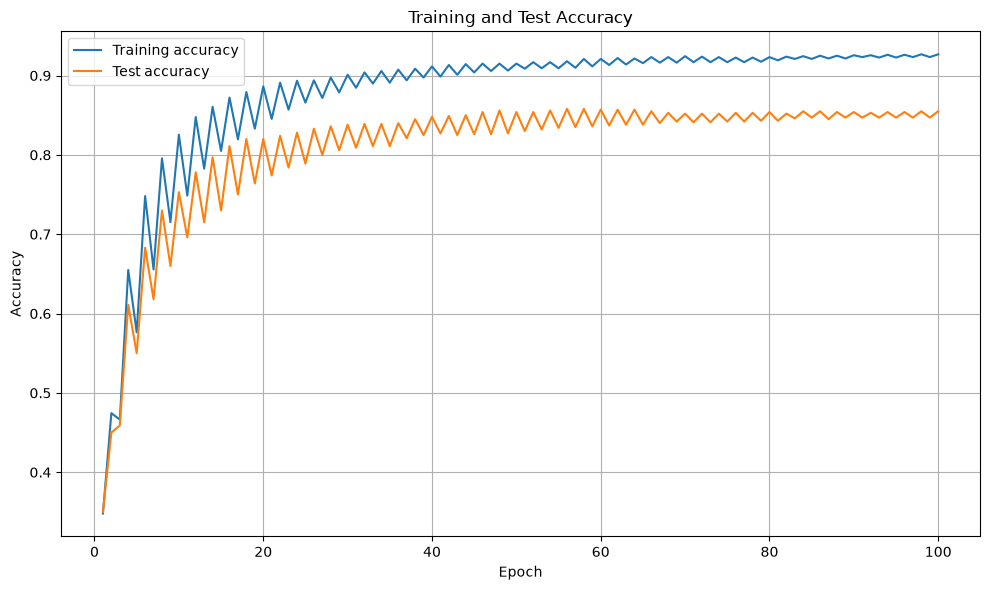

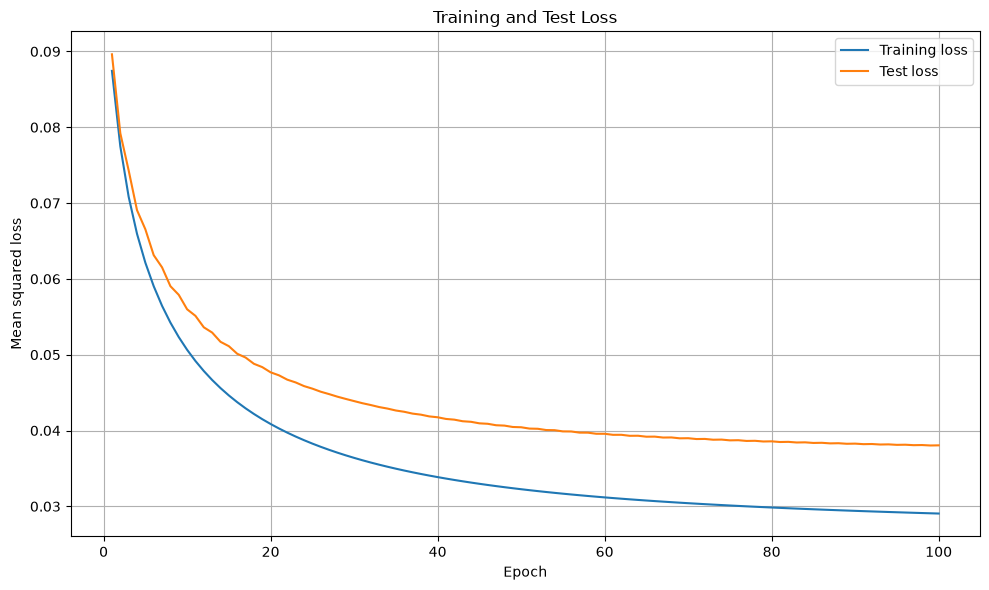

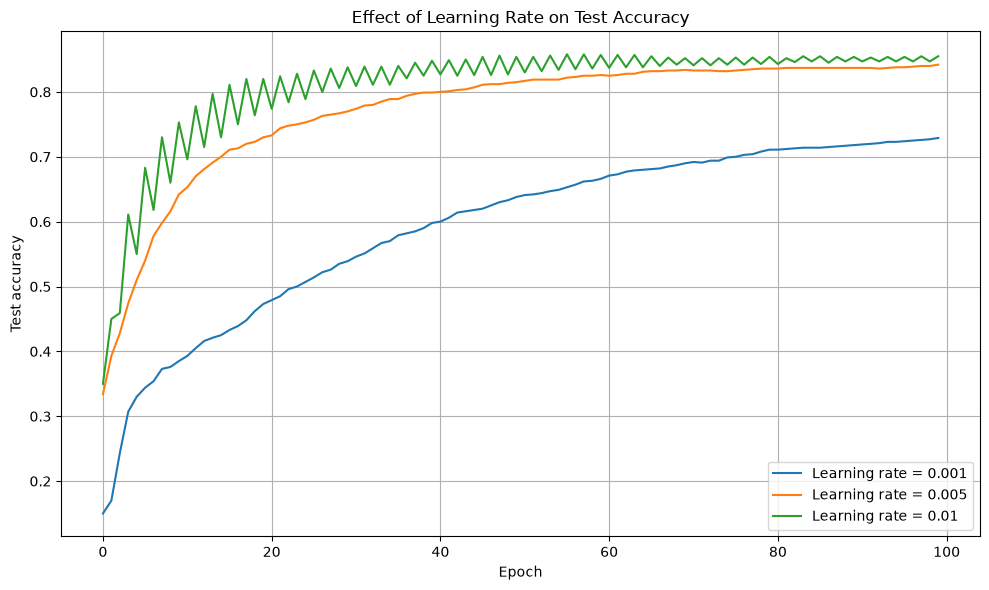


Individual experiments:
   initialization  seed  train_accuracy  test_accuracy  train_loss  test_loss
0           zeros     0        0.924429          0.865    0.028125   0.036861
1           zeros     1        0.924429          0.865    0.028125   0.036861
2           zeros     2        0.924429          0.865    0.028125   0.036861
3           zeros     3        0.924429          0.865    0.028125   0.036861
4           zeros     4        0.924429          0.865    0.028125   0.036861
5          normal     0        0.922086          0.864    0.029031   0.037945
6          normal     1        0.917985          0.858    0.029125   0.038348
7          normal     2        0.923257          0.866    0.029053   0.037808
8          normal     3        0.922671          0.862    0.029015   0.037864
9          normal     4        0.923257          0.860    0.028919   0.037956
10        uniform     0        0.923843          0.859    0.028423   0.037121
11        uniform     1        0.924429

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATA
# ============================================================

X_train = pd.read_csv(
    "train_in.csv",
    header=None
).values.astype(float)

y_train = pd.read_csv(
    "train_out.csv",
    header=None
).values.ravel().astype(int)

X_test = pd.read_csv(
    "test_in.csv",
    header=None
).values.astype(float)

y_test = pd.read_csv(
    "test_out.csv",
    header=None
).values.ravel().astype(int)


# ============================================================
# 2. ADD BIAS
# ============================================================

# 256 input features + 1 bias feature = 257
X_train = np.hstack(
    [
        X_train,
        np.ones((X_train.shape[0], 1))
    ]
)

X_test = np.hstack(
    [
        X_test,
        np.ones((X_test.shape[0], 1))
    ]
)


# ============================================================
# 3. ONE-HOT ENCODE TARGETS
# ============================================================

# Convert digit labels into 10-dimensional target vectors.
#
# Example:
# digit 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

Y_train = np.eye(10)[y_train]
Y_test = np.eye(10)[y_test]


# ============================================================
# 4. MULTICLASS PERCEPTRON / LINEAR CLASSIFIER
# ============================================================

def train_perceptron(
    X_train,
    Y_train,
    y_train,
    X_test,
    Y_test,
    y_test,
    learning_rate=0.01,
    epochs=100,
    initialization="normal",
    seed=42
):

    rng = np.random.default_rng(seed)

    n_features = X_train.shape[1]
    n_classes = 10

    # --------------------------------------------------------
    # Weight initialization
    # --------------------------------------------------------

    if initialization == "zeros":

        W = np.zeros(
            (n_features, n_classes)
        )

    elif initialization == "normal":

        W = rng.normal(
            loc=0.0,
            scale=0.01,
            size=(n_features, n_classes)
        )

    elif initialization == "uniform":

        W = rng.uniform(
            low=-0.01,
            high=0.01,
            size=(n_features, n_classes)
        )

    else:

        raise ValueError(
            "Unknown initialization strategy"
        )


    # --------------------------------------------------------
    # Store metrics
    # --------------------------------------------------------

    train_loss = []
    test_loss = []

    train_accuracy = []
    test_accuracy = []


    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(epochs):

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        train_output = X_train @ W


        # ----------------------------------------------------
        # Calculate error
        # ----------------------------------------------------

        error = train_output - Y_train


        # ----------------------------------------------------
        # Calculate gradient
        # ----------------------------------------------------

        gradient = (
            2.0 / X_train.shape[0]
        ) * (
            X_train.T @ error
        )


        # ----------------------------------------------------
        # Gradient descent update
        # ----------------------------------------------------

        W -= learning_rate * gradient


        # ====================================================
        # TRAINING PERFORMANCE
        # ====================================================

        train_output = X_train @ W

        train_predictions = np.argmax(
            train_output,
            axis=1
        )

        current_train_accuracy = np.mean(
            train_predictions == y_train
        )

        current_train_loss = np.mean(
            (train_output - Y_train) ** 2
        )

        train_accuracy.append(
            current_train_accuracy
        )

        train_loss.append(
            current_train_loss
        )


        # ====================================================
        # TEST PERFORMANCE
        # ====================================================

        test_output = X_test @ W

        test_predictions = np.argmax(
            test_output,
            axis=1
        )

        current_test_accuracy = np.mean(
            test_predictions == y_test
        )

        current_test_loss = np.mean(
            (test_output - Y_test) ** 2
        )

        test_accuracy.append(
            current_test_accuracy
        )

        test_loss.append(
            current_test_loss
        )


    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {
        "weights": W,
        "train_loss": np.array(train_loss),
        "test_loss": np.array(test_loss),
        "train_accuracy": np.array(train_accuracy),
        "test_accuracy": np.array(test_accuracy)
    }


# ============================================================
# 5. SINGLE EXPERIMENT
# ============================================================

learning_rate = 0.01
epochs = 100

result = train_perceptron(
    X_train=X_train,
    Y_train=Y_train,
    y_train=y_train,
    X_test=X_test,
    Y_test=Y_test,
    y_test=y_test,
    learning_rate=learning_rate,
    epochs=epochs,
    initialization="normal",
    seed=42
)


# ============================================================
# 6. PRINT FINAL RESULTS
# ============================================================

print(
    f"Final training accuracy: "
    f"{result['train_accuracy'][-1]:.4f}"
)

print(
    f"Final test accuracy: "
    f"{result['test_accuracy'][-1]:.4f}"
)

print(
    f"Best test accuracy: "
    f"{np.max(result['test_accuracy']):.4f}"
)

print(
    f"Final training loss: "
    f"{result['train_loss'][-1]:.6f}"
)

print(
    f"Final test loss: "
    f"{result['test_loss'][-1]:.6f}"
)


# ============================================================
# 7. PLOT ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    result["train_accuracy"],
    label="Training accuracy"
)

plt.plot(
    range(1, epochs + 1),
    result["test_accuracy"],
    label="Test accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Test Accuracy"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 8. PLOT LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    result["train_loss"],
    label="Training loss"
)

plt.plot(
    range(1, epochs + 1),
    result["test_loss"],
    label="Test loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared loss")

plt.title(
    "Training and Test Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 9. LEARNING RATE EXPERIMENT
# ============================================================

learning_rates = [
    0.001,
    0.005,
    0.01
]

learning_rate_results = {}


for lr in learning_rates:

    result_lr = train_perceptron(
        X_train=X_train,
        Y_train=Y_train,
        y_train=y_train,
        X_test=X_test,
        Y_test=Y_test,
        y_test=y_test,
        learning_rate=lr,
        epochs=epochs,
        initialization="normal",
        seed=42
    )

    learning_rate_results[lr] = result_lr


# ============================================================
# 10. PLOT LEARNING RATE RESULTS
# ============================================================

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    plt.plot(
        learning_rate_results[lr]["test_accuracy"],
        label=f"Learning rate = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")

plt.title(
    "Effect of Learning Rate on Test Accuracy"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 11. INITIALIZATION EXPERIMENT
# ============================================================

initializations = [
    "zeros",
    "normal",
    "uniform"
]

seeds = [
    0,
    1,
    2,
    3,
    4
]

experiment_results = []


for initialization in initializations:

    for seed in seeds:

        result_init = train_perceptron(
            X_train=X_train,
            Y_train=Y_train,
            y_train=y_train,
            X_test=X_test,
            Y_test=Y_test,
            y_test=y_test,
            learning_rate=0.01,
            epochs=epochs,
            initialization=initialization,
            seed=seed
        )

        experiment_results.append(
            {
                "initialization": initialization,
                "seed": seed,
                "train_accuracy":
                    result_init["train_accuracy"][-1],
                "test_accuracy":
                    result_init["test_accuracy"][-1],
                "train_loss":
                    result_init["train_loss"][-1],
                "test_loss":
                    result_init["test_loss"][-1]
            }
        )


# ============================================================
# 12. DISPLAY EXPERIMENT RESULTS
# ============================================================

experiment_df = pd.DataFrame(
    experiment_results
)

print("\nIndividual experiments:")
print(experiment_df)


print("\nAverage results:")
print(
    experiment_df
    .groupby("initialization")
    [
        [
            "train_accuracy",
            "test_accuracy",
            "train_loss",
            "test_loss"
        ]
    ]
    .mean()
)


# ============================================================
# 13. TEST ACCURACY RANGE
# ============================================================

print("\nTest accuracy range:")

print(
    f"Minimum: "
    f"{experiment_df['test_accuracy'].min():.4f}"
)

print(
    f"Maximum: "
    f"{experiment_df['test_accuracy'].max():.4f}"
)

The multiclass linear classifier was trained using gradient descent with a weight matrix of size 257 × 10, where the additional input represents the bias. The output for all samples was calculated efficiently using matrix multiplication, and the predicted class was obtained using argmax.

For a learning rate of 0.01 and 100 epochs, the final training accuracy was 92.68%, while the test accuracy was 85.50%. The highest test accuracy observed during training was 85.80%. The training loss decreased continuously, while the test loss also decreased but remained higher than the training loss.

The learning-rate experiment showed that 0.001 converged considerably more slowly than 0.005 and 0.01. The learning rate of 0.01 reached high accuracy much earlier, although its accuracy showed more oscillation between epochs. This demonstrates the effect of the learning rate on convergence speed and stability.

Repeating the experiment with different weight initialization strategies and five random seeds produced test accuracies between 85.8% and 86.6%. The relatively small variation indicates that the estimated performance is reasonably stable for this dataset. Zero initialization produced identical results across runs because it contains no random component.